<a href="https://colab.research.google.com/github/ashikjoel/Project-2-Real-Time-Industrial-Defect-Detection-System-Computer-Vision-/blob/week3/defect_detection_week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

model_path = "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.pt"

print("Model exists:", os.path.exists(model_path))

Model exists: True


In [ ]:
!pip install -q ultralytics onnx onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 102.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

print("Ultralytics loaded successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics loaded successfully!


In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.pt"
)

model.export(
    format="onnx",
    imgsz=640,
    simplify=True
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (6.0 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 361ms
Prepared 2 packages in 50ms
Installed 2 packages in 7ms
 + colorama==0.4.6
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 3.7s, sav

'/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.onnx'

In [ ]:
import os

model_dir = "/content/drive/MyDrive/Industrial_Defect_Detection/models"

for file in os.listdir(model_dir):
    print(file)

best_yolov8n.pt
best_yolov8n.onnx


In [ ]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


#using cpu

In [ ]:
import time
import numpy as np
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.pt"
)

dummy = np.random.randint(
    0, 255,
    (640, 640, 3),
    dtype=np.uint8
)

# Warmup
for _ in range(10):
    model.predict(dummy, verbose=False)

start = time.time()

for _ in range(100):
    model.predict(dummy, verbose=False)

end = time.time()

avg_time = (end - start) / 100

print(f"Average Inference Time: {avg_time*1000:.2f} ms")
print(f"FPS: {1/avg_time:.2f}")

Average Inference Time: 204.82 ms
FPS: 4.88


#using cpu

In [ ]:
import onnxruntime as ort
import numpy as np
import time

session = ort.InferenceSession(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.onnx",
    providers=["CPUExecutionProvider"]
)

input_name = session.get_inputs()[0].name

dummy = np.random.rand(
    1, 3, 640, 640
).astype(np.float32)

# Warmup
for _ in range(10):
    session.run(None, {input_name: dummy})

start = time.time()

for _ in range(100):
    session.run(None, {input_name: dummy})

end = time.time()

avg_time = (end - start) / 100

print(f"ONNX Inference Time: {avg_time*1000:.2f} ms")
print(f"ONNX FPS: {1/avg_time:.2f}")

ONNX Inference Time: 171.02 ms
ONNX FPS: 5.85


In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.pt"
)

model.export(
    format="engine",   # TensorRT
    imgsz=640,
    half=True          # FP16 optimization
)

WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (6.0 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 155ms
Prepared 2 packages in 31ms
Installed 2 packages in 6ms
 + colorama==0.4.6
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18..

2026-06-21 02:39:47,441 - [modelopt][onnx] - INFO - Successfully enabled 1 EPs for ORT: ['CPUExecutionProvider']


INFO:modelopt.onnx:Successfully enabled 1 EPs for ORT: ['CPUExecutionProvider']


2026-06-21 02:39:48,116 - [modelopt][onnx] - INFO - Running ONNX Runtime to obtain reference outputs (this may take a while)...


INFO:modelopt.onnx.autocast:Running ONNX Runtime to obtain reference outputs (this may take a while)...


...

2026-06-21 02:39:49,254 - [modelopt][onnx] - WARNING - Did not find  in value info map! Assuming not castable


2026-06-21 02:39:50,590 - [modelopt][onnx] - INFO - Converted 217/231 nodes (93.94%) to fp16


INFO:modelopt.onnx.autocast:Converted 217/231 nodes (93.94%) to fp16


TensorRT: input "images" with shape(1, 3, 640, 640) DataType.FLOAT
TensorRT: output "output0" with shape(1, 10, 8400) DataType.FLOAT
TensorRT: building FP16 engine as /content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine
TensorRT: export success ✅ 313.5s, saved as '/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine' (7.6 MB)

Export complete (315.2s)
Results saved to /content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine imgsz=640 half
Validate:        yolo val task=detect model=/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine imgsz=640 data=/content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/data.yaml half 
Visualize:       https://netron.app


PosixPath('/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine')

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.pt"
)

model.export(
    format="engine",
    imgsz=640,
    half=True
)

WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (6.0 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.1s, saved as '/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.onnx' (11.7 MB)

TensorRT: starting export with TensorRT 11.1.0.106...
TensorRT: converting ONNX to FP16 mixed precision with ModelOpt AutoCast...
2026-06-21 02:50:10,443 - [modelopt][onnx] - WARNING - Shared constants were detected and duplicated accordingly.


2026-06-21 02:50:10,555 - [modelopt][onnx] - INFO - Successfully enabled 1 EPs for ORT: ['CPUExecutionProvider']


INFO:modelopt.onnx:Successfully enabled 1 EPs for ORT: ['CPUExecutionProvider']


2026-06-21 02:50:10,558 - [modelopt][onnx] - INFO - Running ONNX Runtime to obtain reference outputs (this may take a while)...


INFO:modelopt.onnx.autocast:Running ONNX Runtime to obtain reference outputs (this may take a while)...


...

2026-06-21 02:50:11,235 - [modelopt][onnx] - WARNING - Did not find  in value info map! Assuming not castable


2026-06-21 02:50:12,078 - [modelopt][onnx] - INFO - Converted 220/231 nodes (95.24%) to fp16


INFO:modelopt.onnx.autocast:Converted 220/231 nodes (95.24%) to fp16


TensorRT: input "images" with shape(1, 3, 640, 640) DataType.FLOAT
TensorRT: output "output0" with shape(1, 10, 8400) DataType.FLOAT
TensorRT: building FP16 engine as /content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine
TensorRT: export success ✅ 125.1s, saved as '/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine' (7.6 MB)

Export complete (125.2s)
Results saved to /content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine imgsz=640 half
Validate:        yolo val task=detect model=/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine imgsz=640 data=/content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/data.yaml half 
Visualize:       https://netron.app


PosixPath('/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine')

In [ ]:
import os

engine_path = "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine"

print("Exists:", os.path.exists(engine_path))
print("Size (MB):", os.path.getsize(engine_path)/(1024*1024))

Exists: True
Size (MB): 7.566954612731934


#using gpu

In [ ]:
import time
import numpy as np
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine"
)

dummy = np.random.randint(
    0, 255,
    (640, 640, 3),
    dtype=np.uint8
)

# Warmup
for _ in range(10):
    model.predict(dummy, verbose=False)

start = time.time()

for _ in range(100):
    model.predict(dummy, verbose=False)

end = time.time()

avg_time = (end - start) / 100

print(f"TensorRT Inference Time: {avg_time*1000:.2f} ms")
print(f"TensorRT FPS: {1/avg_time:.2f}")

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading /content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine for TensorRT inference...
TensorRT Inference Time: 4.64 ms
TensorRT FPS: 215.49


#testing the model

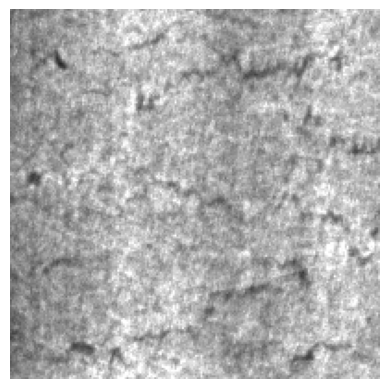

In [ ]:
from matplotlib import pyplot as plt
import cv2

img = cv2.imread("/content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/val/crazing_242.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import time
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine"
)

image_path = "/content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/val/crazing_242.jpg"

# Warmup
for _ in range(10):
    model.predict(image_path, verbose=False)

start = time.time()

for _ in range(100):
    model.predict(image_path, verbose=False)

end = time.time()

avg_time = (end - start) / 100

print(f"Inference Time: {avg_time*1000:.2f} ms")
print(f"FPS: {1/avg_time:.2f}")

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading /content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine for TensorRT inference...
Inference Time: 10.20 ms
FPS: 98.05


In [ ]:
results = model.predict(image_path, verbose=False)

for r in results:
    print("Class IDs:", r.boxes.cls)
    print("Class Names:", model.names)

Class IDs: tensor([0., 0.], device='cuda:0')
Class Names: {0: 'crazing', 1: 'inclusion', 2: 'patches', 3: 'pitted_surface', 4: 'rolled-in_scale', 5: 'scratches'}


In [ ]:
results = model.predict(image_path, verbose=False)

for box in results[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])

    print(
        f"Defect: {model.names[cls_id]} | Confidence: {conf:.2f}"
    )

Defect: crazing | Confidence: 0.53
Defect: crazing | Confidence: 0.36


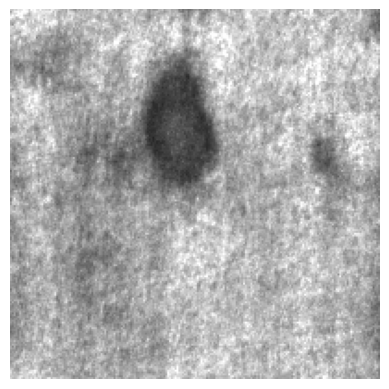

In [ ]:
from matplotlib import pyplot as plt
import cv2

img = cv2.imread("/content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/train/patches_135.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading /content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine for TensorRT inference...

image 1/1 /content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/train/patches_135.jpg: 640x640 1 patches, 3.5ms
Speed: 3.8ms preprocess, 3.5ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


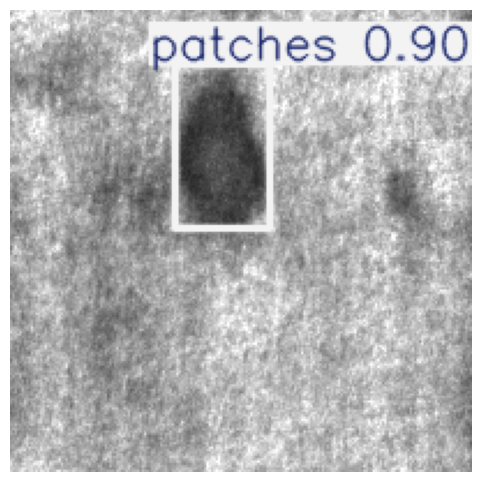

In [ ]:
from ultralytics import YOLO
from matplotlib import pyplot as plt
import cv2

# Load model (.pt, .onnx, or .engine)
model = YOLO(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine"
)

# Run prediction
results = model.predict(
    "/content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/train/patches_135.jpg",
    conf=0.25
)

# Draw boxes and labels
annotated_img = results[0].plot()

# Convert BGR to RGB
annotated_img = cv2.cvtColor(
    annotated_img,
    cv2.COLOR_BGR2RGB
)

# Display
plt.figure(figsize=(6,6))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()

In [ ]:
results = model.predict(
    "/content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/train/patches_135.jpg",
    conf=0.1
)

print(results[0].boxes)


image 1/1 /content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/train/patches_135.jpg: 640x640 1 patches, 3.5ms
Speed: 2.8ms preprocess, 3.5ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([2.], device='cuda:0')
conf: tensor([0.9038], device='cuda:0')
data: tensor([[ 71.2891,  23.9844, 112.4609,  94.8438,   0.9038,   2.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (200, 200)
shape: torch.Size([1, 6])
xywh: tensor([[91.8750, 59.4141, 41.1719, 70.8594]], device='cuda:0')
xywhn: tensor([[0.4594, 0.2971, 0.2059, 0.3543]], device='cuda:0')
xyxy: tensor([[ 71.2891,  23.9844, 112.4609,  94.8438]], device='cuda:0')
xyxyn: tensor([[0.3564, 0.1199, 0.5623, 0.4742]], device='cuda:0')


WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading /content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine for TensorRT inference...

image 1/1 /content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/train/inclusion_9.jpg: 640x640 1 inclusion, 3.5ms
Speed: 2.4ms preprocess, 3.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


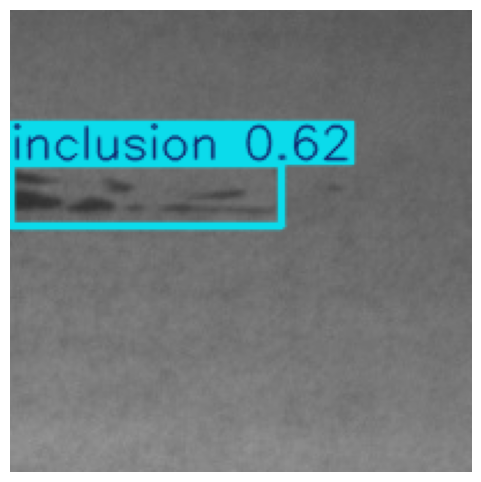

In [ ]:
from ultralytics import YOLO
from matplotlib import pyplot as plt
import cv2

# Load model (.pt, .onnx, or .engine)
model = YOLO(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine"
)

# Run prediction
results = model.predict(
    "/content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/train/inclusion_9.jpg",
    conf=0.25
)

# Draw boxes and labels
annotated_img = results[0].plot()

# Convert BGR to RGB
annotated_img = cv2.cvtColor(
    annotated_img,
    cv2.COLOR_BGR2RGB
)

# Display
plt.figure(figsize=(6,6))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading /content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine for TensorRT inference...

image 1/1 /content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/train/crazing_76.jpg: 640x640 2 crazings, 3.4ms
Speed: 2.6ms preprocess, 3.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


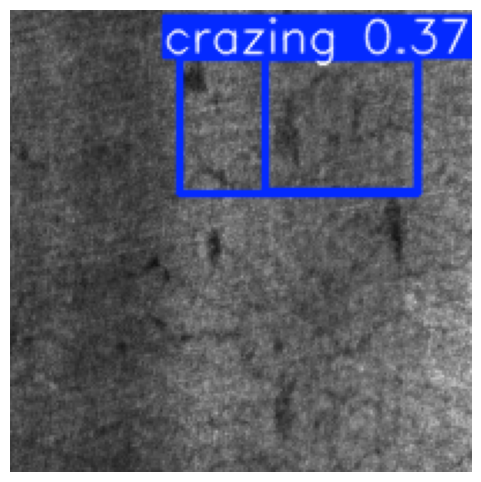

In [ ]:
from ultralytics import YOLO
from matplotlib import pyplot as plt
import cv2

# Load model (.pt, .onnx, or .engine)
model = YOLO(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine"
)

# Run prediction
results = model.predict(
    "/content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/train/crazing_76.jpg",
    conf=0.25
)

# Draw boxes and labels
annotated_img = results[0].plot()

# Convert BGR to RGB
annotated_img = cv2.cvtColor(
    annotated_img,
    cv2.COLOR_BGR2RGB
)

# Display
plt.figure(figsize=(6,6))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading /content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine for TensorRT inference...

image 1/1 /content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/train/pitted_surface_137.jpg: 640x640 1 pitted_surface, 3.4ms
Speed: 2.4ms preprocess, 3.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


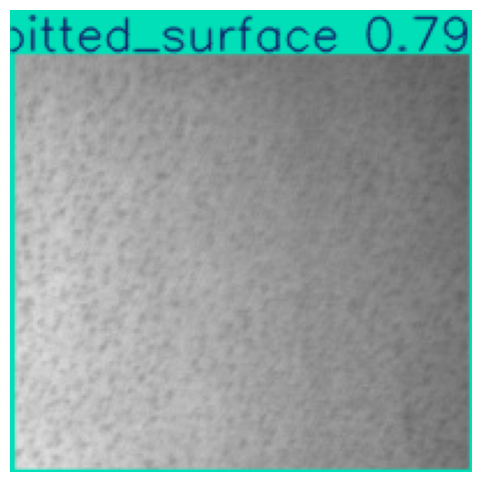

In [ ]:
from ultralytics import YOLO
from matplotlib import pyplot as plt
import cv2

# Load model (.pt, .onnx, or .engine)
model = YOLO(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine"
)

# Run prediction
results = model.predict(
    "/content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/train/pitted_surface_137.jpg",
    conf=0.25
)

# Draw boxes and labels
annotated_img = results[0].plot()

# Convert BGR to RGB
annotated_img = cv2.cvtColor(
    annotated_img,
    cv2.COLOR_BGR2RGB
)

# Display
plt.figure(figsize=(6,6))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading /content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine for TensorRT inference...

image 1/1 /content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/train/rolled-in_scale_132.jpg: 640x640 2 rolled-in_scales, 3.4ms
Speed: 2.3ms preprocess, 3.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


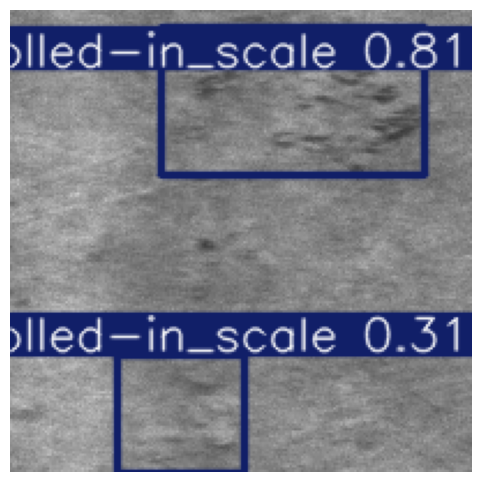

In [ ]:
from ultralytics import YOLO
from matplotlib import pyplot as plt
import cv2

# Load model (.pt, .onnx, or .engine)
model = YOLO(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine"
)

# Run prediction
results = model.predict(
    "/content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/train/rolled-in_scale_132.jpg",
    conf=0.25
)

# Draw boxes and labels
annotated_img = results[0].plot()

# Convert BGR to RGB
annotated_img = cv2.cvtColor(
    annotated_img,
    cv2.COLOR_BGR2RGB
)

# Display
plt.figure(figsize=(6,6))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading /content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine for TensorRT inference...

image 1/1 /content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/val/patches_275.jpg: 640x640 2 patchess, 3.5ms
Speed: 5.7ms preprocess, 3.5ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)


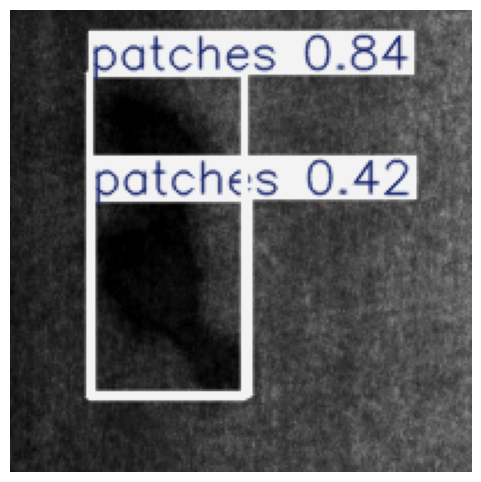

In [ ]:
from ultralytics import YOLO
from matplotlib import pyplot as plt
import cv2

# Load model (.pt, .onnx, or .engine)
model = YOLO(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine"
)

# Run prediction
results = model.predict(
    "/content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/val/patches_275.jpg",
    conf=0.25
)

# Draw boxes and labels
annotated_img = results[0].plot()

# Convert BGR to RGB
annotated_img = cv2.cvtColor(
    annotated_img,
    cv2.COLOR_BGR2RGB
)

# Display
plt.figure(figsize=(6,6))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading /content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine for TensorRT inference...

image 1/1 /content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/val/patches_276.jpg: 640x640 4 patchess, 3.5ms
Speed: 3.6ms preprocess, 3.5ms inference, 9.0ms postprocess per image at shape (1, 3, 640, 640)


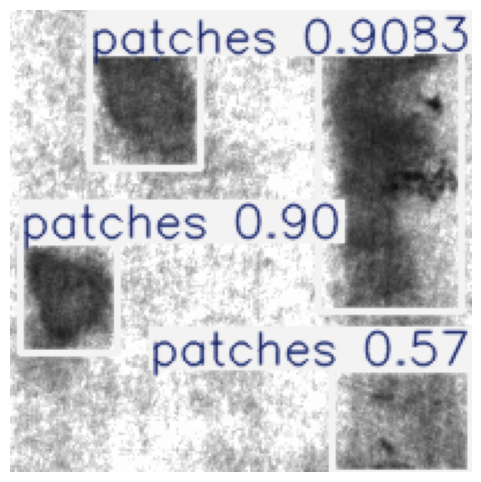

In [ ]:
from ultralytics import YOLO
from matplotlib import pyplot as plt
import cv2

# Load model (.pt, .onnx, or .engine)
model = YOLO(
    "/content/drive/MyDrive/Industrial_Defect_Detection/models/best_yolov8n.engine"
)

# Run prediction
results = model.predict(
    "/content/drive/MyDrive/Industrial_Defect_Detection/yolo_dataset/images/val/patches_276.jpg",
    conf=0.25
)

# Draw boxes and labels
annotated_img = results[0].plot()

# Convert BGR to RGB
annotated_img = cv2.cvtColor(
    annotated_img,
    cv2.COLOR_BGR2RGB
)

# Display
plt.figure(figsize=(6,6))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()